# Barrier Gate Sweep

This notebook showcases the effect of the barrier gate on various physical quantities throughout the device as we sweep its voltage bias.

### 0. Setup

#### - Imports

In [2]:
import sys
import importlib
from pathlib import Path
import numpy as np

REPO_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit")
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nextnano_analysis as nna

#### - Helper functions

In [16]:
from pathlib import Path
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_xqd_potential_gif(
    sweep_root: str | Path,
    out_gif: str | Path,
    bias_folder: str = "bias_00000",
    rel_file: str = "potential_1d_x_QD.dat",
    duration_s: float = 0.35,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    subtract_reference: str | None = None,  # None | "x0" | "xmin"
):
    """
    Create a GIF of potential_1d_x_QD.dat over a V_BG sweep.

    subtract_reference:
      - None  : plot raw potential
      - "x0"  : plot phi(x) - phi(x=0) for each frame (highlights shape changes)
      - "xmin": plot phi(x) - phi(x at min x)
    """
    try:
        import imageio.v2 as imageio
    except Exception as e:
        raise ImportError("Missing dependency 'imageio'. Install with: pip install imageio") from e

    sweep_root = Path(sweep_root)
    out_gif = Path(out_gif)
    out_gif.parent.mkdir(parents=True, exist_ok=True)

    # Find subruns that contain the target file
    subruns = sorted([p for p in sweep_root.iterdir()
                      if p.is_dir() and (p / bias_folder / rel_file).exists()])
    if not subruns:
        raise FileNotFoundError(f"No subruns with {bias_folder}/{rel_file} found under {sweep_root}")

    # Parse V_BG from folder name like: ...__V_BG_-0.2_...
    def parse_vbg(folder_name: str) -> float:
        m = re.search(r"__V_BG_(-?\d+(?:\.\d+)?)_", folder_name)
        if m:
            return float(m.group(1))
        raise ValueError(f"Could not parse V_BG from folder name: {folder_name}")

    runs = [(parse_vbg(r.name), r) for r in subruns]
    runs.sort(key=lambda t: t[0], reverse=True)  # 0, -0.2, ... descending

    # Preload curves and compute global y-limits (unless user provides)
    series = []
    ymins, ymaxs = [], []

    for vbg, r in runs:
        df = pd.read_csv(r / bias_folder / rel_file, delim_whitespace=True, comment="#")
        xcol, ycol = df.columns[0], df.columns[-1]
        x = df[xcol].to_numpy()
        y = df[ycol].to_numpy()

        if subtract_reference == "x0":
            i0 = int(np.argmin(np.abs(x - 0.0)))
            y = y - y[i0]
        elif subtract_reference == "xmin":
            y = y - y[0]

        series.append((vbg, x, y, xcol))
        ymins.append(np.nanmin(y))
        ymaxs.append(np.nanmax(y))

    if ylim is None:
        pad = 0.05 * (max(ymaxs) - min(ymins) + 1e-12)
        ylim = (min(ymins) - pad, max(ymaxs) + pad)

    # Render frames
    frames = []
    for vbg, x, y, xcol in series:
        fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=160)
        ax.plot(x, y, linewidth=2)

        ax.set_title(f"x_QD potential   V_BG = {vbg:g} V")
        ax.set_xlabel(xcol)
        ax.set_ylabel("Potential (V)" if subtract_reference is None else "ΔPotential (V)")

        if xlim is not None:
            ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.grid(True, alpha=0.25)
        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png")
        plt.close(fig)
        buf.seek(0)
        frames.append(imageio.imread(buf))

    imageio.mimsave(out_gif, frames, duration=duration_s, loop=0)
    return out_gif

### 1. Empty QD

#### 1.1 Running the simulation sweep

In [19]:
# Empty-QD 2D input file
INPUT_2D_EMPTY = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/Single_Empty_Quantum_Dot_2D.in")

# Sweep: -2 -> +2 in steps of 0.2, plus extra positive points
VBG_main  = np.round(np.arange(-2.0,  2.0 + 1e-12, 0.2), 10).tolist()
VBG_extra = [5.0, 10.0, 25.0, 50.0]
VBG = list(dict.fromkeys(VBG_main + VBG_extra))  # preserve order, remove duplicates

sweep_variables = {"V_BG": VBG}

# This will overwrite the existing sweep folder contents if you keep overwrite=True + delete_old_files=True
sw = nna.sweep_with_nn_sweep(
    INPUT_2D_EMPTY,
    sweep_variables=sweep_variables,
    delete_old_files=True,
    delete_input_files=False,
    overwrite=True,
    show_log=True,
    convergenceCheck=True,
    parallel_limit=1,
)

print("Done. Sweep points:", len(VBG))
print("Sweep output root should be under:", REPO_ROOT / "runs")
print(sw)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Empty_Quantum_Dot_2D_sweep__V_BG/Single_Empty_Quantum_Dot_2D__V_BG_-2.0_ --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/Single_Empty_Quantum_Dot_2D__V_BG_-2.0_.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                          

#### 1.2 Lateral Dot Potential vs V_BG

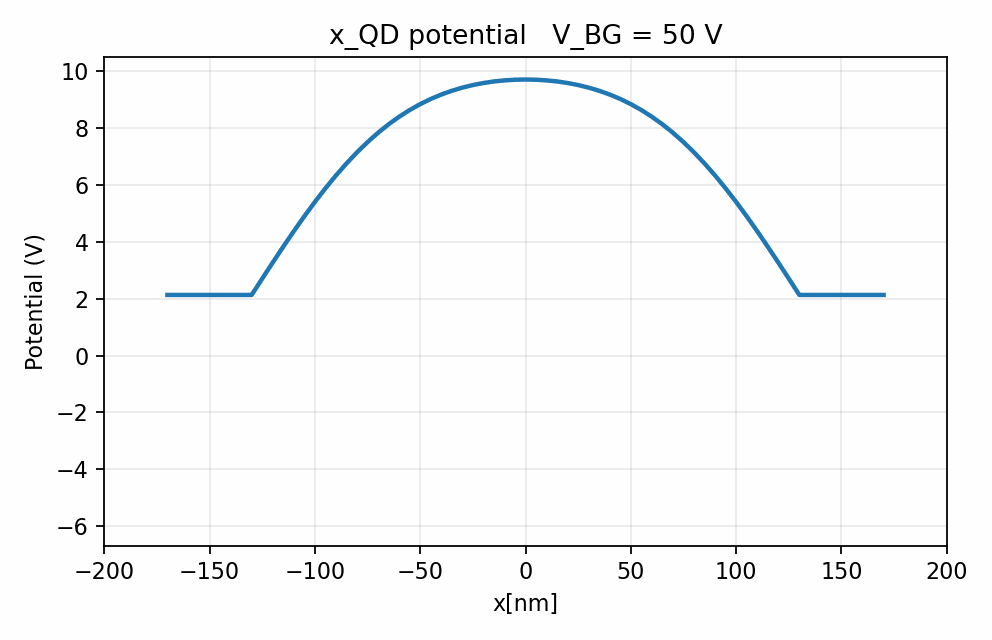

In [20]:
from pathlib import Path
from IPython.display import Image, display

SWEEP_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Empty_Quantum_Dot_2D_sweep__V_BG")

gif_path = make_xqd_potential_gif(
    sweep_root=SWEEP_ROOT,
    out_gif=SWEEP_ROOT / "xQD_potential_vs_VBG.gif",
    duration_s=500,          # per frame
    xlim=(-200, 200),
    subtract_reference=None   # keep absolute potential
)

display(Image(filename=str(gif_path)))

### 2. QD with Accummulation

#### 2.1 Running the simulation sweep

In [21]:
# 2DHG QD 2D input file
INPUT_2D_2DHG = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/Single_Quantum_Dot_2D.in")

# Sweep: -2 -> +2 in steps of 0.2, plus extra positive points
VBG_main  = np.round(np.arange(-2.0,  2.0 + 1e-12, 0.2), 10).tolist()
VBG_extra = [5.0, 10.0, 25.0, 50.0]
VBG = list(dict.fromkeys(VBG_main + VBG_extra))  # preserve order, remove duplicates

sweep_variables = {"V_BG": VBG}

# This will overwrite the existing sweep folder contents if you keep overwrite=True + delete_old_files=True
sw_2 = nna.sweep_with_nn_sweep(
    INPUT_2D_2DHG,
    sweep_variables=sweep_variables,
    delete_old_files=True,
    delete_input_files=False,
    overwrite=True,
    show_log=True,
    convergenceCheck=True,
    parallel_limit=1,
)

print("Done. Sweep points:", len(VBG))
print("Sweep output root should be under:", REPO_ROOT / "runs")
print(sw_2)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_2D_sweep__V_BG/Single_Quantum_Dot_2D__V_BG_-2.0_ --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/2d/Single_Quantum_Dot_2D__V_BG_-2.0_.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                            

#### 2.2 Lateral Dot Potential vs V_BG

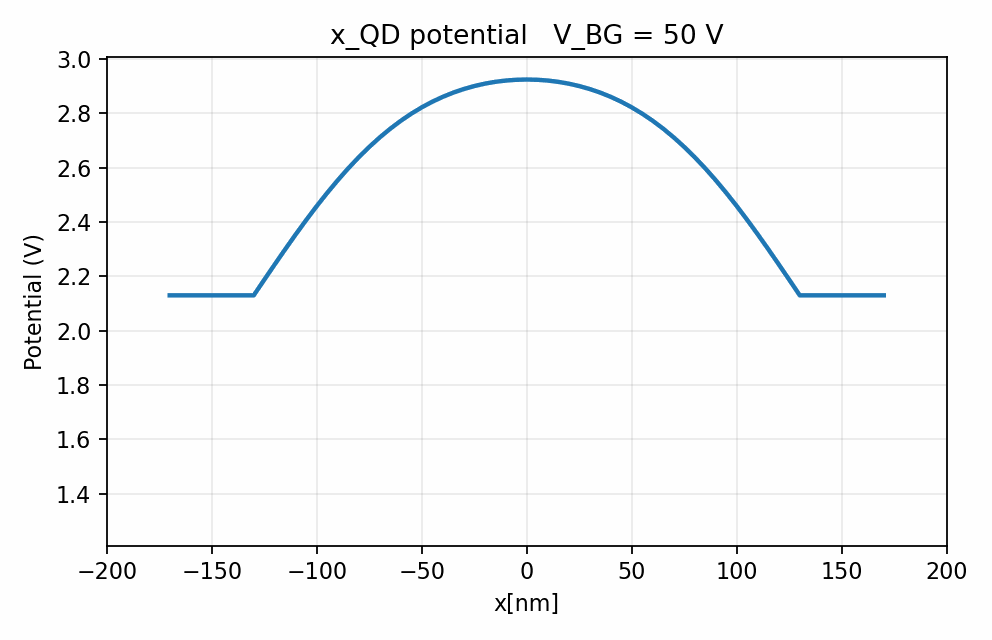

In [22]:
from pathlib import Path
from IPython.display import Image, display

SWEEP_2_ROOT = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_2D_sweep__V_BG")

gif_path = make_xqd_potential_gif(
    sweep_root=SWEEP_2_ROOT,
    out_gif=SWEEP_2_ROOT / "2DHG_xQD_potential_vs_VBG.gif",
    duration_s=500,
    xlim=(-200, 200),
    subtract_reference=None  # use None if you want absolute potential instead
)

display(Image(filename=str(gif_path)))